 normal  albedo  roughness    psnr   ssim  lpips    mae                 config
   0.00    0.00       0.00 23.9616 0.8515 0.1046 0.0275    n=0.0, a=0.0, r=0.0
   0.00    0.00       0.01 23.9670 0.8496 0.1017 0.0276   n=0.0, a=0.0, r=0.01
   0.00    0.00       0.10 24.0980 0.8558 0.1031 0.0269    n=0.0, a=0.0, r=0.1
   0.00    0.01       0.00 24.0676 0.8546 0.1009 0.0267   n=0.0, a=0.01, r=0.0
   0.00    0.01       0.01     NaN    NaN    NaN    NaN  n=0.0, a=0.01, r=0.01
   0.00    0.01       0.10 23.9473 0.8550 0.1039 0.0273   n=0.0, a=0.01, r=0.1
   0.00    0.10       0.00 23.9178 0.8534 0.1046 0.0280    n=0.0, a=0.1, r=0.0
   0.00    0.10       0.01     NaN    NaN    NaN    NaN   n=0.0, a=0.1, r=0.01
   0.00    0.10       0.10 23.9962 0.8546 0.1016 0.0272    n=0.0, a=0.1, r=0.1
   0.01    0.00       0.00 24.1991 0.8554 0.0984 0.0264   n=0.01, a=0.0, r=0.0
   0.01    0.00       0.01     NaN    NaN    NaN    NaN  n=0.01, a=0.0, r=0.01
   0.01    0.00       0.10 23.9051 0.8548 0.1012 0.0

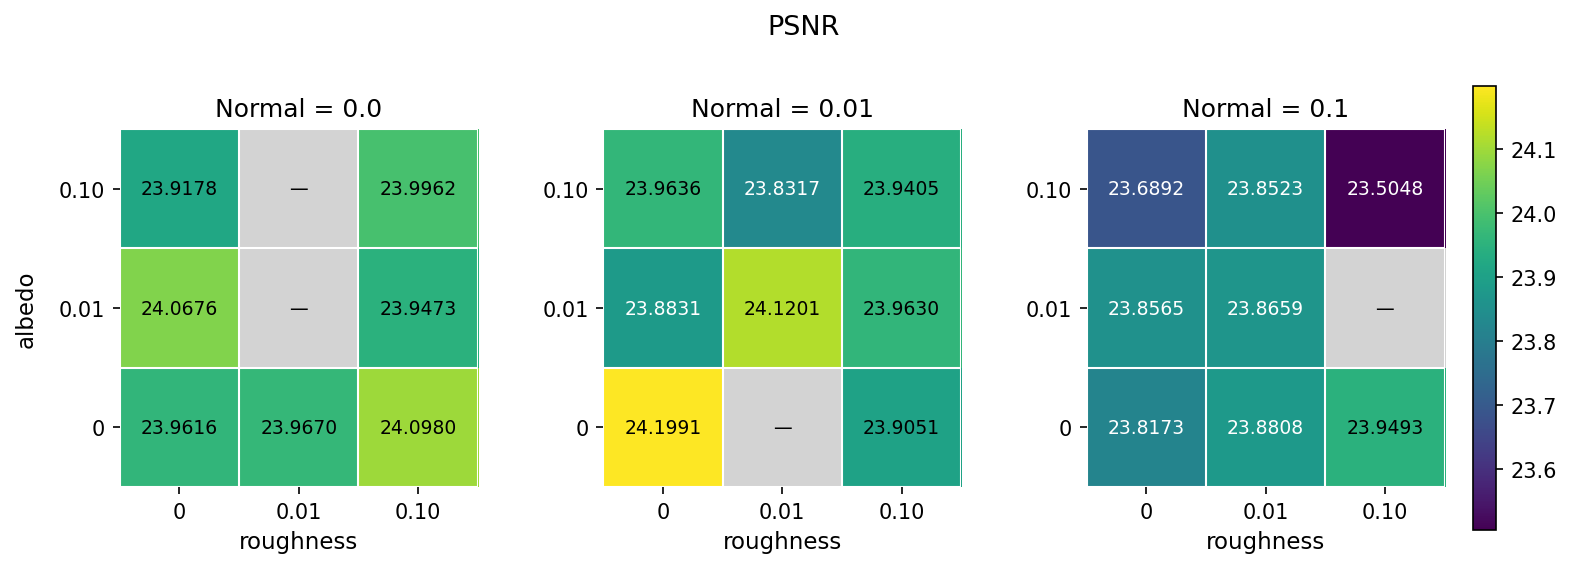

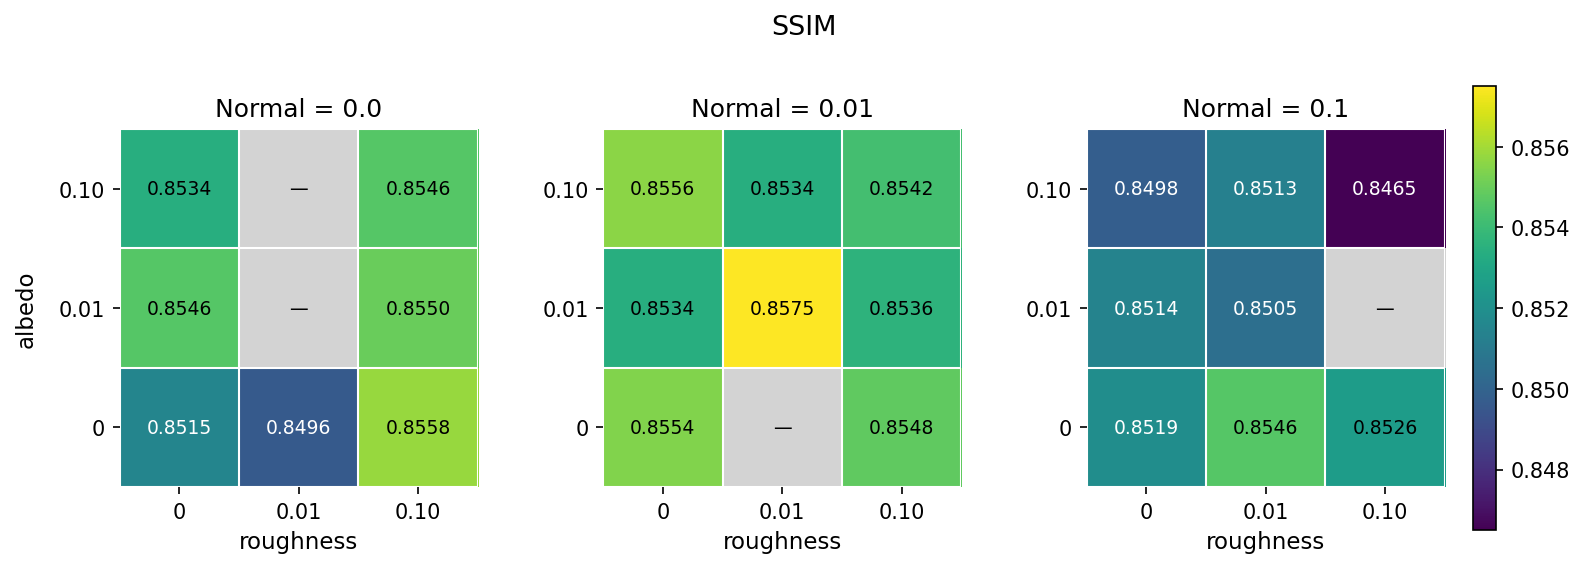

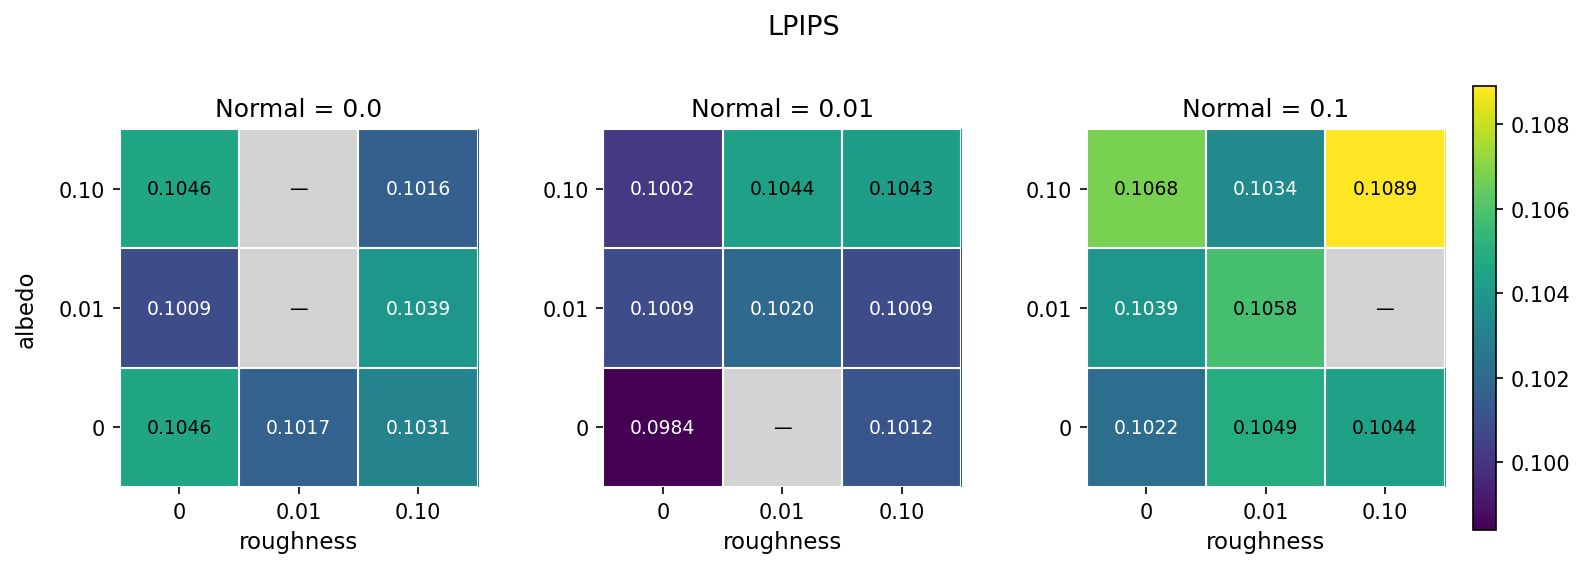

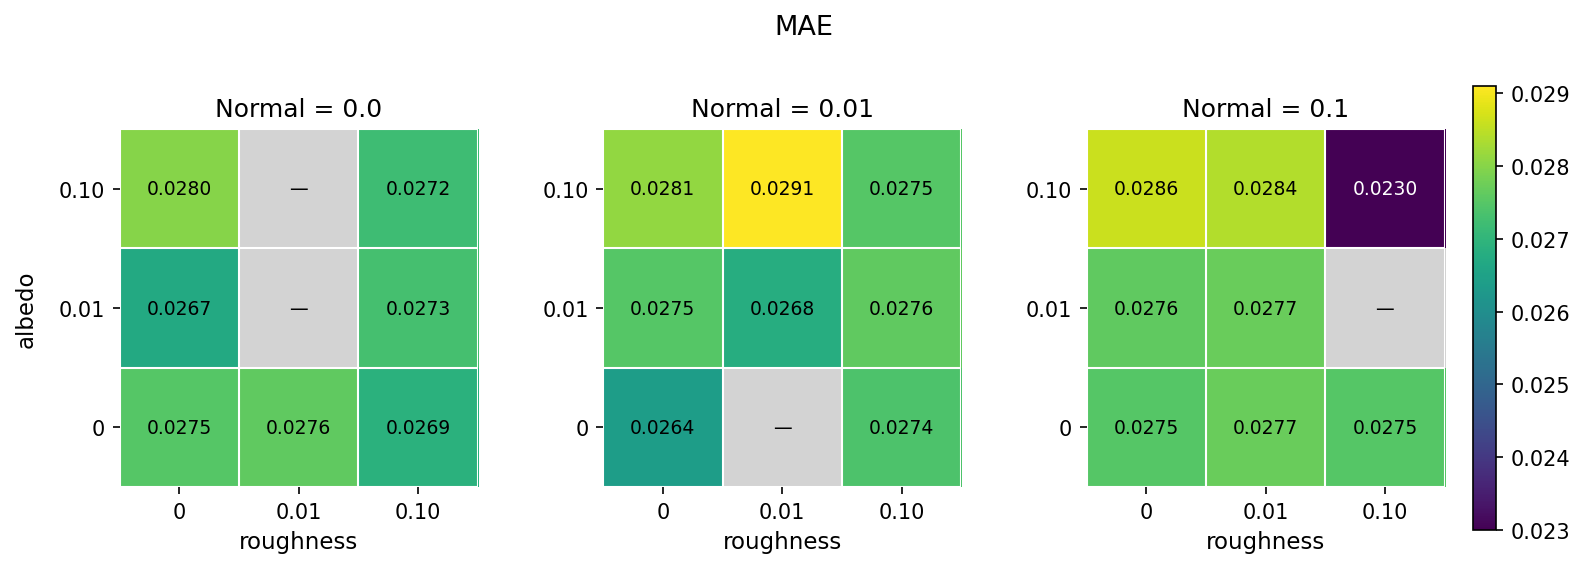

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


raw = """
normal,albedo,roughness,psnr,ssim,lpips,mae
0.1,0.1,0.01,23.8523,0.8513,0.1034,0.0284
0.1,0.1,0.0,23.6892,0.8498,0.1068,0.0286
0.1,0.01,0.01,23.8659,0.8505,0.1058,0.0277
0.1,0.01,0.0,23.8565,0.8514,0.1039,0.0276
0.1,0.0,0.1,23.9493,0.8526,0.1044,0.0275
0.1,0.0,0.01,23.8808,0.8546,0.1049,0.0277
0.01,0.1,0.1,23.9405,0.8542,0.1043,0.0275
0.01,0.1,0.01,23.8317,0.8534,0.1044,0.0291
0.01,0.1,0.0,23.9636,0.8556,0.1002,0.0281
0.0,0.1,0.1,23.7666,0.8519,0.1079,0.0284
0.01,0.01,0.1,23.9630,0.8536,0.1009,0.0276
0.01,0.01,0.0,23.8831,0.8534,0.1009,0.0275
0.01,0.0,0.1,23.9051,0.8548,0.1012,0.0274
0.0,0.01,0.1,23.9473,0.8550,0.1039,0.0273
0.0,0.1,0.1,23.9962,0.8546,0.1016,0.0272
0.0,0.0,0.0,23.9616,0.8515,0.1046,0.0275
0.01,0.0,0.0,24.1991,0.8554,0.0984,0.0264
0.1,0.0,0.0,23.8173,0.8519,0.1022,0.0275
0.0,0.01,0.0,24.0676,0.8546,0.1009,0.0267
0.0,0.1,0.0,23.9178,0.8534,0.1046,0.0280
0.0,0.0,0.01,23.9670,0.8496,0.1017,0.0276
0.0,0.0,0.1,24.0980,0.8558,0.1031,0.0269
0.1,0.1,0.1,23.5048,0.8465,0.1089,0.0230
0.01,0.01,0.01,24.1201,0.8575,0.1020,0.0268
"""

# Read into DataFrame
df_input = pd.read_csv(io.StringIO(raw.strip()))
# Normalize numeric columns to floats (they already are)
df_input[['normal','albedo','roughness']] = df_input[['normal','albedo','roughness']].astype(float)

# Build full grid of the three regularization values (0.0, 0.01, 0.1)
vals = [0.0, 0.01, 0.1]
full = pd.MultiIndex.from_product([vals, vals, vals], names=['normal','albedo','roughness']).to_frame(index=False)

# Merge provided results into the full grid; missing combos become NaN.
# If duplicates existed in the original data, keep last occurrence (pandas does that by default on merge if we drop duplicates)
# But we'll detect duplicates first for transparency.
duplicates = df_input[df_input.duplicated(subset=['normal','albedo','roughness'], keep=False)]
dup_warning = None
if not duplicates.empty:
    dup_warning = "Warning: duplicate rows found for the same configuration. I'll keep the last occurrence for each duplicate key."
    # Keep last occurrence:
    df_input = df_input.drop_duplicates(subset=['normal','albedo','roughness'], keep='last')

df = full.merge(df_input, on=['normal','albedo','roughness'], how='left').sort_values(['normal','albedo','roughness'])
df = df.reset_index(drop=True)

# For display, create a string label for each config
df['config'] = df.apply(lambda r: f"n={r['normal']}, a={r['albedo']}, r={r['roughness']}", axis=1)

print(df.to_string(index=False))

# Helper to save and return filenames
saved_files = []

# Plotting heatmaps: one figure per (metric, fixed normal) pair — this avoids subplots and obeys the "one chart per figure" rule.
metrics = {
    'psnr': {'label': 'PSNR', 'higher_better': True},
    'ssim': {'label': 'SSIM', 'higher_better': True},
    'lpips': {'label': 'LPIPS', 'higher_better': False},
    'mae': {'label': 'MAE', 'higher_better': False},
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 150,
})

def fmt_tick(x):
    if float(x).is_integer():
        return f"{int(x)}"
    return f"{x:.2f}"

for metric, meta in metrics.items():
    # collect pivots for each normal value
    pivots = []
    for n in vals:
        pivot = df[df['normal'] == n].pivot(index='albedo', columns='roughness', values=metric)
        pivot = pivot.reindex(index=vals, columns=vals)  # ensures order 0.0,0.01,0.1
        pivots.append(pivot)

    # common vmin/vmax (ignore NaNs)
    stacked = np.array([p.values for p in pivots], dtype=float)
    vmin = np.nanmin(stacked)
    vmax = np.nanmax(stacked)
    if np.isfinite(vmin) and np.isfinite(vmax) and (vmax - vmin) < 1e-6:
        pad = abs(vmin) * 0.01 + 1e-3
        vmin -= pad
        vmax += pad

    # create figure with 1x3 horizontal panels
    n_panels = len(vals)
    fig, axes = plt.subplots(1, n_panels, figsize=(12, 4), constrained_layout=False)
    if n_panels == 1:
        axes = [axes]

    # use modern colormap (avoid deprecated call)
    cmap = mpl.colormaps.get_cmap('viridis').copy()
    cmap.set_bad(color='lightgray')  # NaN cells in light gray

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    for ax, pivot, n in zip(axes, pivots, vals):
        arr = pivot.values.astype(float)
        masked = np.ma.masked_invalid(arr)
        im = ax.imshow(masked, origin='lower', interpolation='nearest',
               aspect='equal', cmap=cmap, norm=norm)
        # im = ax.imshow(masked, vmin=vmin, vmax=vmax, origin='lower',
        #                interpolation='nearest', aspect='equal', cmap=cmap, norm=norm)

        # ticks & labels
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_xticklabels([fmt_tick(x) for x in pivot.columns])
        ax.set_yticklabels([fmt_tick(x) for x in pivot.index])
        ax.set_xlabel("roughness")
        ax.set_title(f"Normal = {n}")

        # only the leftmost axes gets the ylabel (visible on slides)
        if ax is axes[0]:
            ax.set_ylabel("albedo", labelpad=10)

        # crisp white grid lines between cells
        ax.set_xticks(np.arange(-.5, len(pivot.columns), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(pivot.index), 1), minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=1)
        ax.tick_params(which='minor', length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # annotate cells with contrast-aware text color using luminance of the cmap color
        for (i, j), val in np.ndenumerate(arr):
            if np.isnan(val):
                txt = "—"
                color = "black"
            else:
                txt = f"{val:.4f}"
                # normalized value for colormap lookup
                if np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin:
                    norm_val = (val - vmin) / (vmax - vmin)
                    norm_val = np.clip(norm_val, 0.0, 1.0)
                else:
                    norm_val = 0.5
                rgba = cmap(norm_val)
                # compute luminance (rec. 709)
                r, g, b = rgba[0], rgba[1], rgba[2]
                luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
                # white text on dark cells (low luminance), black on light cells
                color = 'white' if luminance < 0.5 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, color=color)

    # place a single shared colorbar to the right
    # use a ScalarMappable to attach the same norm & cmap
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # required for colorbar
    # adjust space for colorbar and suptitle manually to avoid tight_layout warnings
    fig.subplots_adjust(left=0.12, right=0.92, top=0.86, bottom=0.12, wspace=0.35)
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.06, pad=0.02)
    fig.suptitle(f"{meta['label']}", fontsize=13)
    plt.show(fig)
